In [75]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'customer_id': [1, 2, 3],
        'purchase1': [100, 200, 150],
        'purchase2': [80, 120, 130]}
df = pd.DataFrame(data)


In [76]:
df['total_purchase'] = df['purchase1'] + df['purchase2']
df

,customer_id,purchase1,purchase2,total_purchase
0,1,100,80,180
1,2,200,120,320
2,3,150,130,280


In [77]:
df['total'] = df['total_purchase'].sum()
df

,customer_id,purchase1,purchase2,total_purchase,total
0,1,100,80,180,780
1,2,200,120,320,780
2,3,150,130,280,780


In [78]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'A', 'B', 'B', 'C'],
        'income': [5000, 6000, 5500, 6200, 5800]}
df = pd.DataFrame(data)
df

,region,income
0,A,5000
1,A,6000
2,B,5500
3,B,6200
4,C,5800


In [79]:
avg_income = df.groupby('region')['income'].mean().reset_index()
avg_income

,region,income
0,A,5500.0
1,B,5850.0
2,C,5800.0


In [80]:
avg_income.rename(columns={'income':'avg_income'},inplace= True)
avg_income

,region,avg_income
0,A,5500.0
1,B,5850.0
2,C,5800.0


In [81]:
# transform() : 매개변수의 기준에 따라 계산하여 원래 행의 개수만큼 반환
avg_income = df.groupby('region')['income'].transform('mean')
avg_income

0    5500.0
1    5500.0
2    5850.0
3    5850.0
4    5800.0
Name: income, dtype: float64

In [82]:
df['region_avg_income']=avg_income
df

,region,income,region_avg_income
0,A,5000,5500.0
1,A,6000,5500.0
2,B,5500,5850.0
3,B,6200,5850.0
4,C,5800,5800.0


In [83]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'person': ['X', 'Y', 'Z'],
        'income': [4000, 5000, 6000]}
df = pd.DataFrame(data)


mean_income = df['income'].mean()

df['income_diff'] = df['income'] - mean_income
df['income_diff'] = df['income_diff'].astype(int)
df

,person,income,income_diff
0,X,4000,-1000
1,Y,5000,0
2,Z,6000,1000


In [84]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, 5000, 6000, 4500]}
df = pd.DataFrame(data)
df
mean_income = df['avg_income'].mean()

def categorize_income(x):
    if x > mean_income:
        return '높음'
    elif x == mean_income:
        return '보통'
    else:
        return '낮음'
    
df['income_level'] = df['avg_income'].apply(categorize_income)
df

,region,avg_income,income_level
0,A,5500,높음
1,B,5000,낮음
2,C,6000,높음
3,D,4500,낮음


In [85]:
# 예시 데이터프레임 생성
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, None, 6000, 4500]}
df = pd.DataFrame(data)
df

,region,avg_income
0,A,5500.0
1,B,NaN
2,C,6000.0
3,D,4500.0


In [86]:
df.isnull().sum()
df.isna()

,region,avg_income
0,False,False
1,False,True
2,False,False
3,False,False


In [87]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)

mean_age = df['age'].mean()
df['age'] = df['age'].fillna(mean_age)
df

,name,age
0,Alice,25.0
1,Bob,27.5
2,Charlie,30.0
3,David,27.5


In [88]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'student': ['A', 'B', 'C', 'D', 'E'],
        'score': [80, np.nan, 90, np.nan, 85]}
df = pd.DataFrame(data)

df

,student,score
0,A,80.0
1,B,NaN
2,C,90.0
3,D,NaN
4,E,85.0


In [89]:
nan_indices = df[df['score'].isnull()].index
nan_indices

RangeIndex(start=1, stop=5, step=2)

In [90]:
np.random.seed(0)

In [91]:
# 무작위 대체
df.loc[nan_indices,'score'] = np.random.choice(df['score'].dropna(),size=len(nan_indices))
df

,student,score
0,A,80.0
1,B,80.0
2,C,90.0
3,D,90.0
4,E,85.0


In [92]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [93]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 예시 데이터프레임 생성
data = {'feature1': [1.0, 2.1, np.nan, 4.3, 5.2],
        'feature2': [3.2, np.nan, 1.8, 2.5, 4.0]}
df = pd.DataFrame(data)
df

,feature1,feature2
0,1.0,3.2
1,2.1,NaN
2,NaN,1.8
3,4.3,2.5
4,5.2,4.0


In [94]:
df.columns

Index(['feature1', 'feature2'], dtype='str')

In [96]:
# 다중대치법
# IterativeImputer : 반복값 결측값 대체 모델 (10번 반복, 시드 고정)
imputer = IterativeImputer(max_iter =10, random_state = 0)
df_imputed = pd.DataFrame(imputer.fit_transform(df),columns=df.columns)
df_imputed

,feature1,feature2
0,1.000000,3.200000
1,2.100000,2.874009
2,3.148439,1.800000
3,4.300000,2.500000
4,5.200000,4.000000


In [101]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)
df

,value
0,10
1,12
2,14
3,16
4,18
5,100


In [ ]:
#사분위수 계산

Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 -Q1
print(Q1,Q3,IQR)



12.5 17.5 5.0


In [99]:
# 이상값 기준 계산

lower_bound = Q1 -1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound,upper_bound)

5.0 25.0


In [106]:
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
outliers

,value
5,100


In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [5,10, 12, 14, 16, 18, 100,120,140]}
df = pd.DataFrame(data)
df

,value
0,5
1,10
2,12
3,14
4,16
5,18
6,100
7,120
8,140


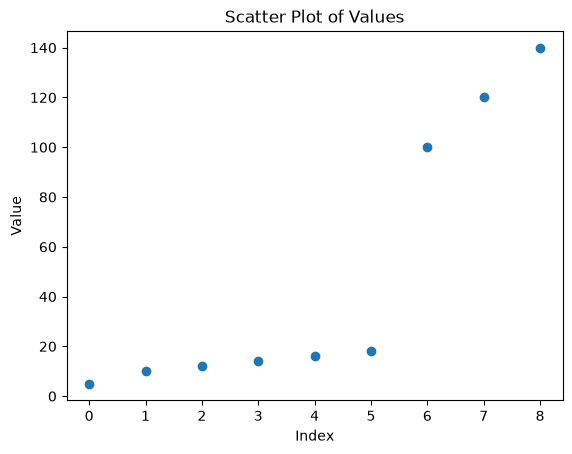

In [111]:

# 산점도 그리기
plt.scatter(df.index, df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

In [114]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [115]:
mean = df['score'].mean()
std = df['score'].std()
print(mean,std)

90.0 15.811388300841896


In [116]:
df['z_score']= (df['score']-mean) / std
df

,score,z_score
0,70,-1.264911
1,80,-0.632456
2,90,0.000000
3,100,0.632456
4,110,1.264911


In [118]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [119]:
scaler = StandardScaler()


df['z_score']=scaler.fit_transform(df[['score']])
df

,score,z_score
0,70,-1.414214
1,80,-0.707107
2,90,0.000000
3,100,0.707107
4,110,1.414214


In [120]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [121]:

# 최소값과 최대값 계산
min_val = df['score'].min()
max_val = df['score'].max()

print(min_val,max_val)

70 110


In [122]:

# [0-1] 변환 적용
df['normalized_score'] = (df['score'] - min_val) / (max_val - min_val)
print(df)

   score  normalized_score
0     70              0.00
1     80              0.25
2     90              0.50
3    100              0.75
4    110              1.00


In [123]:
df

,score,normalized_score
0,70,0.00
1,80,0.25
2,90,0.50
3,100,0.75
4,110,1.00


In [124]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [125]:
scaler = MinMaxScaler()
df['nomalized_score'] = scaler.fit_transform(df[['score']])
df

,score,nomalized_score
0,70,0.00
1,80,0.25
2,90,0.50
3,100,0.75
4,110,1.00


In [126]:
import pandas as pd
from scipy.stats import iqr
# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)
df

,value
0,10
1,12
2,14
3,16
4,18
5,100


In [ ]:
IQR = iqr(df['value'])
q1 = np.percentile(df, 25)
q2 = np.percentile(df, 50) # 중앙값(Median)
q3 = np.percentile(df, 75)
q3 - q1


np.float64(5.0)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = 30
trials = 10000

sample_means = []

for _ in range(trials):
    samples = np.random.randint(1,7,n)       # 1~6까지의 숫자를 랜덤으로 n개 뽑아서 samples에 저장
    sample_means.append(np.mean(samples))    # 
sample_means

[np.float64(3.6666666666666665),
 np.float64(3.2),
 np.float64(3.933333333333333),
 np.float64(3.533333333333333),
 np.float64(3.533333333333333),
 np.float64(3.433333333333333),
 np.float64(3.466666666666667),
 np.float64(3.3666666666666667),
 np.float64(3.3),
 np.float64(4.033333333333333),
 np.float64(3.6),
 np.float64(3.6),
 np.float64(3.3),
 np.float64(3.2333333333333334),
 np.float64(3.566666666666667),
 np.float64(3.6666666666666665),
 np.float64(3.2),
 np.float64(3.2666666666666666),
 np.float64(3.3333333333333335),
 np.float64(3.533333333333333),
 np.float64(3.8666666666666667),
 np.float64(3.6333333333333333),
 np.float64(3.1333333333333333),
 np.float64(3.8666666666666667),
 np.float64(3.6),
 np.float64(4.066666666666666),
 np.float64(3.9),
 np.float64(3.566666666666667),
 np.float64(3.3),
 np.float64(3.3),
 np.float64(3.3666666666666667),
 np.float64(3.6333333333333333),
 np.float64(2.8333333333333335),
 np.float64(3.7333333333333334),
 np.float64(3.433333333333333),
 np.fl

(array([2.57142857e-03, 1.28571429e-03, 7.71428571e-03, 1.80000000e-02,
        3.60000000e-02, 6.42857143e-02, 1.26000000e-01, 1.44000000e-01,
        2.39142857e-01, 5.22000000e-01, 5.29714286e-01, 6.89142857e-01,
        1.29857143e+00, 9.88714286e-01, 1.04014286e+00, 1.59300000e+00,
        1.06200000e+00, 9.30857143e-01, 1.25614286e+00, 6.48000000e-01,
        7.20000000e-01, 2.93142857e-01, 2.49428571e-01, 1.56857143e-01,
        1.36285714e-01, 4.24285714e-02, 2.82857143e-02, 2.18571429e-02,
        6.42857143e-03, 5.14285714e-03]),
 array([2.3       , 2.37777778, 2.45555556, 2.53333333, 2.61111111,
        2.68888889, 2.76666667, 2.84444444, 2.92222222, 3.        ,
        3.07777778, 3.15555556, 3.23333333, 3.31111111, 3.38888889,
        3.46666667, 3.54444444, 3.62222222, 3.7       , 3.77777778,
        3.85555556, 3.93333333, 4.01111111, 4.08888889, 4.16666667,
        4.24444444, 4.32222222, 4.4       , 4.47777778, 4.55555556,
        4.63333333]),
 <BarContainer object of

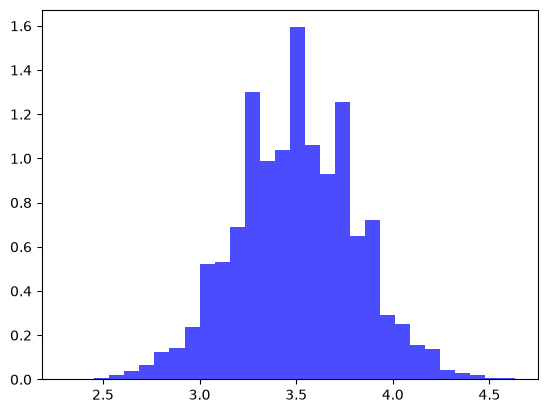

In [140]:
plt.hist(sample_means,
        bins = 30,
        density = True, 
        alpha = 0.7, 
        color = 'blue'
        )


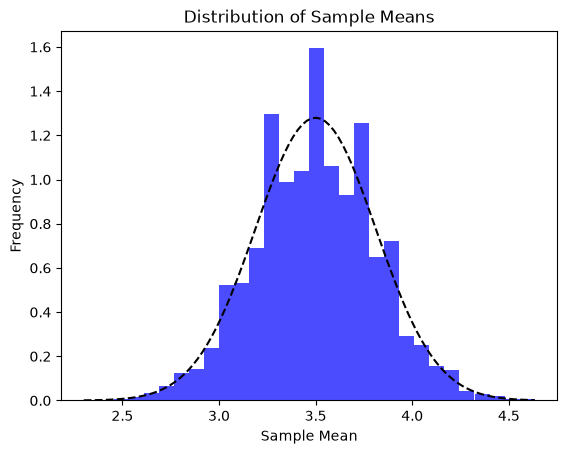

In [160]:
# 히스토그램 그리기
plt.hist(sample_means,
        bins = 30,
        density = True, 
        alpha = 0.7, 
        color = 'blue'
        )
# 정규분포 곡선 그리기
from scipy.stats import norm
mu = 3.5 # 주사위 눈의 평균
sigma = np.sqrt(35/12) / np.sqrt(n)  # 주사위 눈의 분산과 표본 크기를 이용한 표준편차

x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x,norm.pdf(x,mu,sigma), 'k--')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()